In [1]:
from pathlib import Path
from furax.interfaces.toast.observation import ToastObservation
import matplotlib.pyplot as plt

## Loading the data from toast

In [2]:
filename = Path("tests/data/test_obs.h5")
if not filename.exists():
    raise FileNotFoundError(f"{filename} does not exist")

obs = ToastObservation.from_file(filename)

## Get the TOD, HWP angles

Map-making model
$$
\mathbf{d} = \mathbf{P} \mathbf{s} + \mathbf{n}
$$
- $\mathbf{P}$ is the **pointing matrix** (scanning pattern and telescope orientation)
- $\mathbf{s}$ is the sky signal defined by the Stokes parameters.
- $\mathbf{d}$ is time-ordered data.

In [3]:
import numpy as np
from furax.math.quaternion import to_lonlat_angles

In [27]:
tod = obs.get_tods() # shape: (n_detectors, n_samples)
sample_mask = obs.get_sample_mask() # shape: (n_samples,)
scanning_mask = obs.get_scanning_mask()

azimuth = obs.get_azimuth() # shape: (n_samples,)
elevation = obs.get_elevation() # shape: (n_samples,)

hwp_angles = obs.get_hwp_angles() # shape: (n_samples,)
time = obs.get_elapsed_times() # shape: (n_samples,)

# qfull = np.roll(obs._get_expanded_quats(), 1, axis=-1) # shape: (n_detectors, n_samples, 4) # quarternions

bor_quat = obs.get_boresight_quaternions() # shape: (n_samples, 4)
det_quat = obs.get_detector_quaternions() # shape: (n_samples, 4)

#### Quaternion
A quaternion is written as
$$
q = w + x i + y j + z k
$$
or as the vector form
$$
q = [w, x, y, z]
$$
where
- $w$ is the scalar part
- $[x, y, z]$ is the vector part
- Norm: $|q| = \sqrt{w^2 + x^2 + y^2 + z^2} = 1$ for the rotations (unit quaternions)

The reason to use quaternion is to represent 3D rotation without *gimbal lock*. 

#### Quaternion rotation of a vector
Let's say you have a 3D vector $v = [v_x, v_y, v_z]$ (e.g. pointing direction)

To rotate $v$ using quaternion $q$:
1. Represent $v$ as a pure quaternion
$$
v = [0, v_x, v_y, v_z]
$$. 
If $q = [w, x, y, z]$ is a **unit quaternion** representing a rotation, the rotated vector $v'$ is
$$
v'_q = q \cdot v_q \cdot q^{-1}
$$
- $q^{-1} = [w, -x, -y, -z]$ the inverse of a unit quaternion is its conjugate.
- To multiply the quaternion
$$
q_1 \cdot q_2 = [w_1, \mathbf{v}_1] \cdot [w_2, \mathbf{v}_2] = [w_1 w_2 - \mathbf{v}_1 \cdot \mathbf{v}_2, w_1 v_2 + w_2 v_1 + v_1 \times v_2]
$$

In [8]:
# lon, lat, _ = to_lonlat_angles(qfull) # convert the quarternions to lon, lat
lon_, lat_ = obs.get_detector_pointing_lonlat(thin_samples=10, use_scanning_mask=False, use_degrees=False) # get the detector lon, lat

In [9]:
colors = ["violet", "orange"]

#### Detector trajectory

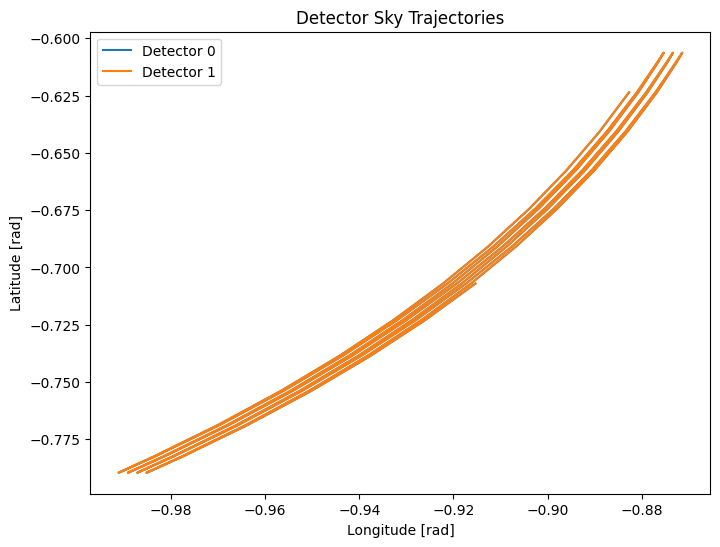

In [141]:
n_detectors = lon_.shape[0]

plt.figure(figsize=(8, 6))
for i in range(n_detectors):
    # plt.plot(lon[i, :], lat[i, :], color=colors[i], label=f'Detector qfull {i}')
    plt.plot(lon_[i, :], lat_[i, :], label=f'Detector {i}')

plt.xlabel("Longitude [rad]")
plt.ylabel("Latitude [rad]")
plt.title("Detector Sky Trajectories")
plt.legend()

# plt.xlim(lon.min(), lon.max())
# plt.ylim(lat.min(), lat.max())

plt.show()

#### Constant elevation scan of SO

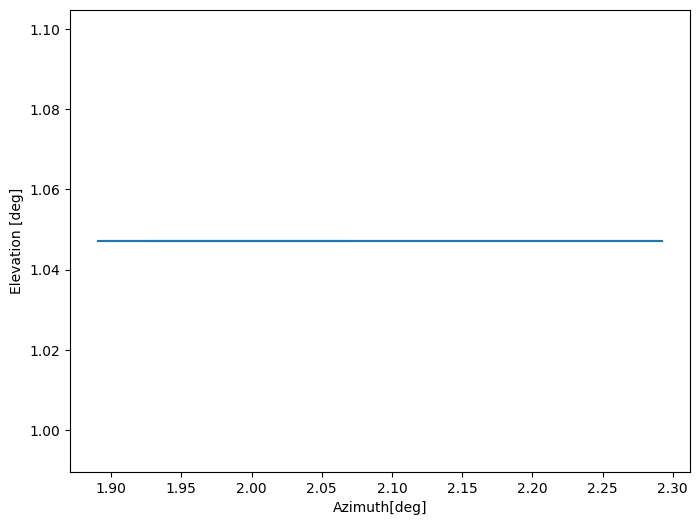

In [11]:
plt.figure(figsize=(8, 6))

plt.plot(azimuth, elevation)
plt.xlabel("Azimuth[deg]")
plt.ylabel("Elevation [deg]")
plt.show()

plt.close()

#### TOD

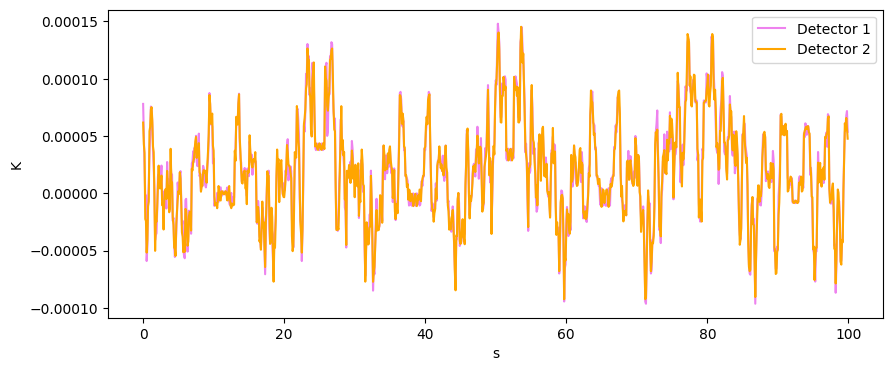

In [12]:
plt.figure(figsize=(10,4))
plt.plot(time, tod[0], color="violet", label="Detector 1")
plt.plot(time, tod[1], color="orange", label="Detector 2")

plt.xlabel("s")
plt.ylabel(r"K")
plt.legend()
plt.show()
plt.close()

#### HWP angles

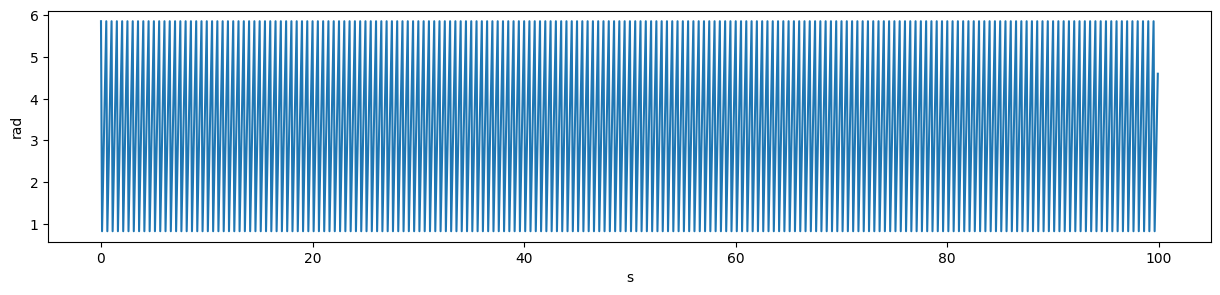

In [60]:
plt.figure(figsize=(15, 3))
plt.plot(time, hwp_angles)

plt.xlabel("s")
plt.ylabel(r"rad")
plt.show()
plt.close()

## Landscape info

In [14]:
from furax.obs.landscapes import HealpixLandscape

In [15]:
# Define sky resolution
nside = 512
landscape = HealpixLandscape(nside=nside, stokes='IQU')
n_pix = landscape.shape[0]

print(f"Sky map: {n_pix} pixels with {landscape.stokes} Stokes parameters")
print(f"Total sky parameters: {landscape.size}")

Sky map: 3145728 pixels with IQU Stokes parameters
Total sky parameters: 9437184


In [46]:
pointing, spin_angles = obs.get_pointing_and_spin_angles(landscape=landscape)

## Creating a Pointing operator

In [45]:
from furax.mapmaking.pointing import PointingOperator
import jax.numpy as jnp

In [54]:
pointing = PointingOperator.create(landscape, boresight_quaternions=bor_quat, detector_quaternions=det_quat)

In [55]:
vector = landscape.ones()
pointing(vector)

StokesIQU(i=Array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]], dtype=float64), q=Array([[-0.77962557, -0.77170779, -0.76374248, ..., -0.39807524,
        -0.40785231, -0.41758958],
       [-0.77962557, -0.77170779, -0.76374248, ..., -0.39807524,
        -0.40785231, -0.41758958]], dtype=float64), u=Array([[-1.17990846, -1.18510215, -1.19025099, ..., -1.35703209,
        -1.35412573, -1.35115467],
       [-1.17990846, -1.18510215, -1.19025099, ..., -1.35703209,
        -1.35412573, -1.35115467]], dtype=float64))

## HWP and Polarizer

In [65]:
from furax.obs import HWPOperator, LinearPolarizerOperator, QURotationOperator
from furax.math.quaternion import to_gamma_angles

In [67]:
gamma = to_gamma_angles(det_quat)[:, None]

polarizer = LinearPolarizerOperator.create(tod.shape)
hwp = HWPOperator.create(tod.shape, angles=hwp_angles)
rot = QURotationOperator.create(tod.shape, angles=gamma)

A = polarizer @ rot @ hwp @ pointing

In [206]:
A(vector).shape

(2, 1000)

In [79]:
A.is_square

False

In [80]:
A.out_structure ## output shape and dtype

ShapeDtypeStruct(shape=(2, 1000), dtype=float64)

In [81]:
A.in_structure ## input shape and dtype

StokesIQU(i=ShapeDtypeStruct(shape=(3145728,), dtype=float64), q=ShapeDtypeStruct(shape=(3145728,), dtype=float64), u=ShapeDtypeStruct(shape=(3145728,), dtype=float64))

## Noise model

- **White noise**: random statistical fluctuation
  - Mean: $$\langle n(t) \rangle = 0$$
  - Variance: $$\langle n(t) n(t') \rangle = \sigma^2 \delta(t - t')$$
  - In map-making, noise covariance is diagonal: $$N = \sigma^2 I$$. 
  - The solution: $$s = (A^T A)^{-1} A^T d$$
- **Atmospheric noise** (1/f): atmosphere introduces slow variations (e.g. clouds, water vapor, temperature drift).
  - The noise is correlated and stronger at the low frequencies.
  - Power spectrum density: $$P(f) = \sigma^2 \left( 1 + \left( \dfrac{f + f_0}{f_k} \right)^\alpha \right)$$ where  
    - $f_k$: knee frequency
    - $\alpha \approx -1$
    - $f_0$: offset frequency
  - High frequency $\left( f \gg f_k \right)$: $P(f) \sim \sigma^2$
  - Low frequency $\left( f \ll f_k \right)$: $P(f) \sim \dfrac{1}{f^\alpha}$
  - Toeplitz covariance

#### White noise

In [144]:
from furax.mapmaking.noise import WhiteNoiseModel, AtmosphericNoiseModel
from jax.numpy.fft import rfftfreq
from jax.numpy.fft import rfft

from scipy import signal

In [193]:
# sample rate
timestamps = obs.get_timestamps()
dt = jnp.diff(timestamps).mean()  # average sampling interval
sample_rate = 1.0 / dt

# hwp frequency
dtheta = hwp_angles[2] - hwp_angles[1]
omega = dtheta / dt
hwp_frequency = omega / (2 * jnp.pi)

# frequency
n_samples = tod.shape[1]
f = rfftfreq(n_samples, d=dt)  # array of frequencies in Hz

# PSD with fft
fft_vals = rfft(tod, axis=-1)
Pxx = (fft_vals * fft_vals.conj()).real / n_samples 

# PSD with Welch method
nperseg = tod.shape[1] // 4
f_w, Pxx_w = signal.welch(tod, fs=sample_rate, nperseg=nperseg, axis=1)

In [232]:
print(f"Sample rate: {sample_rate:.2f} Hz")
print(f"HWP frequency: {hwp_frequency:.2f} Hz")

Sample rate: 10.00 Hz
HWP frequency: 2.00 Hz


#### Power Spectral Density

- PSD is how the variance/power of the signal is distributed over frequencies. 
  - If the TOD wiggles slowly, the power at low frequencies.
  - If the TOD wiggles fast, the power at high frequencies.
- **Discrete Fourier transform (DFT):** 
  - For a TOD $$d(t) \qquad t = 0, \Delta t, 2\Delta t, 3 \Delta t, ..., (N-1) \Delta t$$ where 
    - $N$ is the number of sample.
    - $\Delta t$ is the sampling interval. 
  - The **DFT** is: $$ \tilde{d}_k = \sum_{n=0}^{N-1} d_n \, e^{-2 \pi i k n / N}, \quad k = 0, 1, \dots, N-1 $$ where:
    - $d_n = d(n \Delta t)$
    - $k$ indexes the **discrete frequencies**
    - Corresponding frequency: $$ f_k = \frac{k}{N \Delta t} = \frac{k f_s}{N} \quad \text{(Hz)}$$
    - $f_s = 1 / \Delta t$ is the **sample rate**
- **Periodogram**: The power at each frequency is $$P_{xx} = \dfrac{1}{N} \tilde{d}_k \cdot \tilde{d}_k^*$$
- **Welch's method**: for finite-length signal, the PSD estimation using fourier transform is noisy. Welch's method improves this by
  - Splitting the signal into overlapping segments.
  - Windowing each segment (reduce the spectral leakage)
  - Computing periodogram on each segment
  - Averaging the periodogram

#### Comparison between fft and welch method

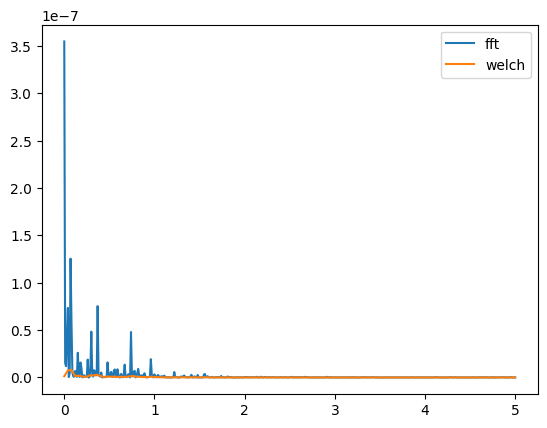

In [194]:
plt.figure()
plt.plot(f, Pxx[0], label="fft")
plt.plot(f_w, Pxx_w[0], label="welch")

plt.legend()
plt.show()

PSD is less noisy with Welch! Yeppi, happy, happy

In [195]:
wn = WhiteNoiseModel.fit_psd_model(f, Pxx, sample_rate=sample_rate, hwp_frequency=hwp_frequency)
wn_w = WhiteNoiseModel.fit_psd_model(f_w, Pxx_w, sample_rate=sample_rate, hwp_frequency=hwp_frequency)

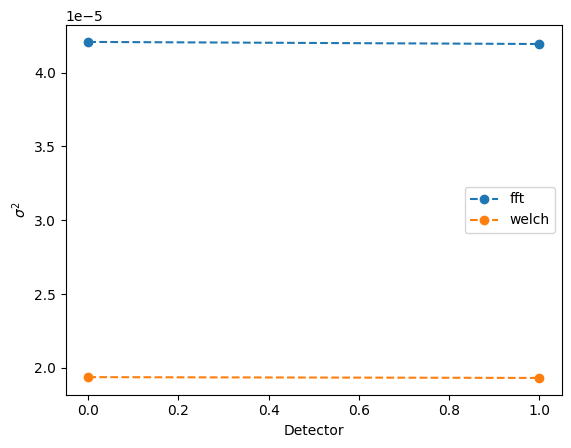

In [196]:
x = np.linspace(1.5, 4.5) * 1e-5
plt.plot(wn.sigma, "--o", label="fft")
plt.plot(wn_w.sigma,  "--o", label="welch")

plt.xlabel("Detector")
plt.ylabel(r"$\sigma^2$")
plt.legend()
plt.show()
plt.close()

So the covariance estimation is lower with Welch

#### Noise covariance inverse

In [240]:
in_structure = A.out_structure
N_inv = wn_w.inverse_operator(in_structure)

In [241]:
N_inv.is_diagonal

True

In [242]:
N_inv.is_symmetric

True

## Map-making operator

In [244]:
# Simple estimation
s = ((A.T @ N_inv @ A).I @ A.T @ N_inv).mv(tod)

### Preconditioner